# 03 Main: Causal Response in the Pacing Selector

Compares response layers inside the same robust pacing selector: predicted response, doubly robust response, and robust causal response.

[forecast] fitting 7 forecasters: blocks=120, dim=48, train_blocks=60
[forecast] point_naive start
[forecast] point_naive done in 0.0s, train_mse=611405, band_radius=4682.58
[forecast] seasonal_ridge start
[forecast] seasonal_ridge done in 0.0s, train_mse=362770, band_radius=3443.88
[forecast] random_feature start
[forecast] random_feature done in 0.0s, train_mse=51775.5, band_radius=1362.16
[forecast] gradient_boosted start
[forecast] gradient_boosted training start: targets=48, train_blocks=60
[forecast] gradient_boosted fitted target 1/48
[forecast] gradient_boosted fitted target 8/48
[forecast] gradient_boosted fitted target 16/48
[forecast] gradient_boosted fitted target 24/48
[forecast] gradient_boosted fitted target 32/48
[forecast] gradient_boosted fitted target 40/48
[forecast] gradient_boosted fitted target 48/48
[forecast] gradient_boosted done in 3.4s, train_mse=276487, band_radius=3027.94
[forecast] numpy_mlp start
[forecast] numpy_mlp training start: epochs=600, hidden=48

/home/apex/Documents/ranking_sys/notebooks/writing/forecast_calibrated_causal_pacing_yield_optimization_streaming_ads/code/src/forecasting.py:375: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)


[forecast] torch_transformer epoch 70/350, loss=0.00613195
[forecast] torch_transformer epoch 140/350, loss=0.00230195
[forecast] torch_transformer epoch 210/350, loss=0.00178256
[forecast] torch_transformer epoch 280/350, loss=0.00090178
[forecast] torch_transformer epoch 350/350, loss=0.000803212
[forecast] torch_transformer inference start: blocks=108
[forecast] torch_transformer done in 1.5s, train_mse=220.718, band_radius=92.8421
[forecast] fitting 7 forecasters: blocks=120, dim=48, train_blocks=60
[forecast] point_naive start
[forecast] point_naive done in 0.0s, train_mse=135745, band_radius=1212.22
[forecast] seasonal_ridge start
[forecast] seasonal_ridge done in 0.0s, train_mse=90852.4, band_radius=966.933
[forecast] random_feature start
[forecast] random_feature done in 0.0s, train_mse=5905.29, band_radius=309.281
[forecast] gradient_boosted start
[forecast] gradient_boosted training start: targets=48, train_blocks=60
[forecast] gradient_boosted fitted target 1/48
[forecast] g

/home/apex/Documents/ranking_sys/notebooks/writing/forecast_calibrated_causal_pacing_yield_optimization_streaming_ads/code/src/forecasting.py:375: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=layers)


[forecast] torch_transformer epoch 70/350, loss=0.0205382
[forecast] torch_transformer epoch 140/350, loss=0.00508065
[forecast] torch_transformer epoch 210/350, loss=0.00295917
[forecast] torch_transformer epoch 280/350, loss=0.00159039
[forecast] torch_transformer epoch 350/350, loss=0.00152671
[forecast] torch_transformer inference start: blocks=108
[forecast] torch_transformer done in 1.3s, train_mse=120.058, band_radius=45.7812


,case,mode,response_estimate,doubly_robust_se,causal_radius_scale,alpha_tau,alpha_m,tau_se,member_se,response_notes,...,budget_violation,member_violation,any_violation,delivery_violation_rate,budget_violation_rate,member_violation_rate,any_violation_rate,mean_delivery_shortfall,mean_budget_overspend,mean_member_violation
0,criteo,predicted_response,0.001488,0.000460,0.000000,0.1,0.1,0.000460,0.003003,context-adjusted doubly robust score with clip...,...,False,False,True,0.033333,0.0,0.0,0.033333,-10052.501382,-552.750394,-25687.057957
1,criteo,doubly_robust_response,0.011844,0.000460,0.304541,0.1,0.1,0.000460,0.003003,context-adjusted doubly robust score with clip...,...,False,False,True,0.033333,0.0,0.0,0.033333,-10052.501382,-552.750394,-25687.057957
2,criteo,robust_causal_response,0.010943,0.000460,1.000000,0.1,0.1,0.000460,0.003003,context-adjusted doubly robust score with clip...,...,False,False,True,0.033333,0.0,0.0,0.033333,-10052.501382,-552.750394,-25687.057957
3,kuairand,predicted_response,0.002632,0.000411,0.000000,0.1,0.1,0.000411,0.051083,insufficient treatment variation; uses conserv...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,kuairand,doubly_robust_response,0.002632,0.000411,1.225344,0.1,0.1,0.000411,0.051083,insufficient treatment variation; uses conserv...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,kuairand,robust_causal_response,0.001316,0.000411,1.000000,0.1,0.1,0.000411,0.051083,insufficient treatment variation; uses conserv...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


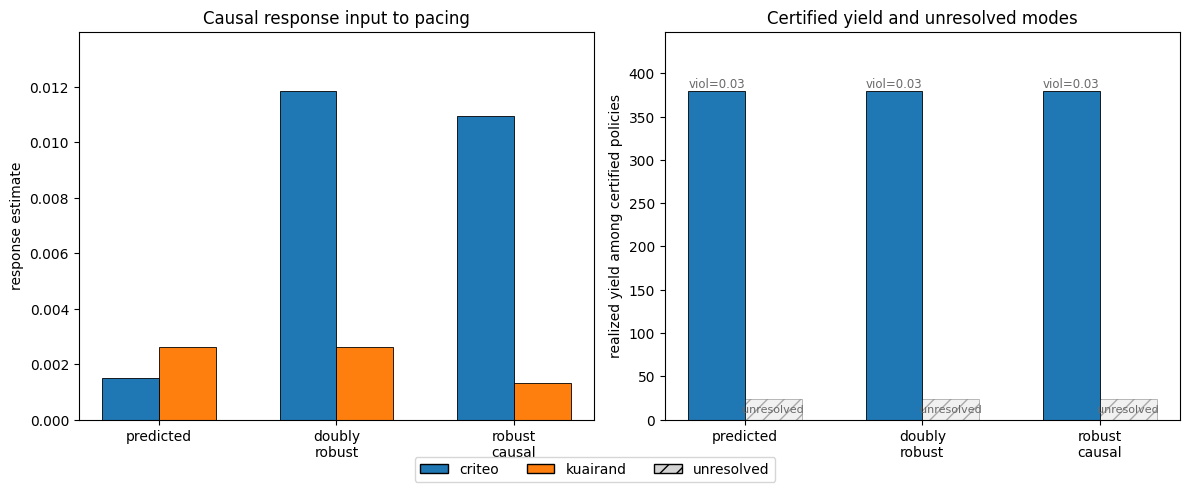

In [1]:
from pathlib import Path
import sys
import pandas as pd

CODE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(CODE_DIR))

from src.experiments import compare_causal_response_modes
from src.figures import plot_causal_modes
from src.tables import write_table

frames = [compare_causal_response_modes(case, max_rows=500_000) for case in ['criteo', 'kuairand']]
df = pd.concat(frames, ignore_index=True)
write_table(df, '03_causal_response_modes.csv')
plot_causal_modes(df, 'main_causal_response_modes.png')
df